
install libraries

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn wfdb pillow nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.5 MB/s eta 0:00:00


In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import wfdb

Create a General Data Inspector

In [3]:
def inspect_data(data, name="Dataset"):
    print("=" * 60)
    print(f"DATASET: {name}")
    print("=" * 60)

    print("\nData type:")
    print(type(data))

    if isinstance(data, pd.DataFrame):

        print("\nShape:")
        print(data.shape)

        print("\nFirst 5 rows:")
        display(data.head())

        print("\nData types:")
        print(data.dtypes)

        print("\nMissing values:")
        print(data.isnull().sum())

        print("\nBasic statistics:")
        display(data.describe(include="all").T)

    elif isinstance(data, np.ndarray):

        print("\nShape:")
        print(data.shape)

        print("\nData type:")
        print(data.dtype)

        print("\nMinimum:", np.min(data))
        print("Maximum:", np.max(data))
        print("Mean:", np.mean(data))

    else:
        print("\nObject successfully loaded.")

TABULAR DATA — CSV

In [4]:
tabular_data = pd.DataFrame({
    "Patient_ID": [101, 102, 103, 104, 105],
    "Age": [45, 52, 61, 38, 70],
    "Gender": ["M", "F", "M", "F", "M"],
    "Cholesterol": [210, 240, 260, 190, 280],
    "Blood_Pressure": [130, 140, 150, 120, 160],
    "Heart_Disease": [0, 1, 1, 0, 1]
})

tabular_data.to_csv("patient_data.csv", index=False)

In [5]:
df_csv = pd.read_csv("patient_data.csv")

inspect_data(df_csv, "CSV Patient Data")

DATASET: CSV Patient Data

Data type:
<class 'pandas.core.frame.DataFrame'>

Shape:
(5, 6)

First 5 rows:


,Patient_ID,Age,Gender,Cholesterol,Blood_Pressure,Heart_Disease
0,101,45,M,210,130,0
1,102,52,F,240,140,1
2,103,61,M,260,150,1
3,104,38,F,190,120,0
4,105,70,M,280,160,1



Data types:
Patient_ID         int64
Age                int64
Gender            object
Cholesterol        int64
Blood_Pressure     int64
Heart_Disease      int64
dtype: object

Missing values:
Patient_ID        0
Age               0
Gender            0
Cholesterol       0
Blood_Pressure    0
Heart_Disease     0
dtype: int64

Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient_ID,5.0,NaN,NaN,NaN,103.0,1.581139,101.0,102.0,103.0,104.0,105.0
Age,5.0,NaN,NaN,NaN,53.2,12.67675,38.0,45.0,52.0,61.0,70.0
Gender,5,2,M,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cholesterol,5.0,NaN,NaN,NaN,236.0,36.469165,190.0,210.0,240.0,260.0,280.0
Blood_Pressure,5.0,NaN,NaN,NaN,140.0,15.811388,120.0,130.0,140.0,150.0,160.0
Heart_Disease,5.0,NaN,NaN,NaN,0.6,0.547723,0.0,0.0,1.0,1.0,1.0



Reading Excel Data



In [6]:
tabular_data.to_excel("patient_data.xlsx", index=False)

In [7]:
df_excel = pd.read_excel("patient_data.xlsx")

inspect_data(df_excel, "Excel Patient Data")

DATASET: Excel Patient Data

Data type:
<class 'pandas.core.frame.DataFrame'>

Shape:
(5, 6)

First 5 rows:


,Patient_ID,Age,Gender,Cholesterol,Blood_Pressure,Heart_Disease
0,101,45,M,210,130,0
1,102,52,F,240,140,1
2,103,61,M,260,150,1
3,104,38,F,190,120,0
4,105,70,M,280,160,1



Data types:
Patient_ID         int64
Age                int64
Gender            object
Cholesterol        int64
Blood_Pressure     int64
Heart_Disease      int64
dtype: object

Missing values:
Patient_ID        0
Age               0
Gender            0
Cholesterol       0
Blood_Pressure    0
Heart_Disease     0
dtype: int64

Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient_ID,5.0,NaN,NaN,NaN,103.0,1.581139,101.0,102.0,103.0,104.0,105.0
Age,5.0,NaN,NaN,NaN,53.2,12.67675,38.0,45.0,52.0,61.0,70.0
Gender,5,2,M,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cholesterol,5.0,NaN,NaN,NaN,236.0,36.469165,190.0,210.0,240.0,260.0,280.0
Blood_Pressure,5.0,NaN,NaN,NaN,140.0,15.811388,120.0,130.0,140.0,150.0,160.0
Heart_Disease,5.0,NaN,NaN,NaN,0.6,0.547723,0.0,0.0,1.0,1.0,1.0


Reading JSON Data

In [8]:
tabular_data.to_json(
    "patient_data.json",
    orient="records",
    indent=4
)

In [9]:
df_json = pd.read_json("patient_data.json")

inspect_data(df_json, "JSON Patient Data")

DATASET: JSON Patient Data

Data type:
<class 'pandas.core.frame.DataFrame'>

Shape:
(5, 6)

First 5 rows:


,Patient_ID,Age,Gender,Cholesterol,Blood_Pressure,Heart_Disease
0,101,45,M,210,130,0
1,102,52,F,240,140,1
2,103,61,M,260,150,1
3,104,38,F,190,120,0
4,105,70,M,280,160,1



Data types:
Patient_ID         int64
Age                int64
Gender            object
Cholesterol        int64
Blood_Pressure     int64
Heart_Disease      int64
dtype: object

Missing values:
Patient_ID        0
Age               0
Gender            0
Cholesterol       0
Blood_Pressure    0
Heart_Disease     0
dtype: int64

Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient_ID,5.0,NaN,NaN,NaN,103.0,1.581139,101.0,102.0,103.0,104.0,105.0
Age,5.0,NaN,NaN,NaN,53.2,12.67675,38.0,45.0,52.0,61.0,70.0
Gender,5,2,M,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cholesterol,5.0,NaN,NaN,NaN,236.0,36.469165,190.0,210.0,240.0,260.0,280.0
Blood_Pressure,5.0,NaN,NaN,NaN,140.0,15.811388,120.0,130.0,140.0,150.0,160.0
Heart_Disease,5.0,NaN,NaN,NaN,0.6,0.547723,0.0,0.0,1.0,1.0,1.0



Automatic CSV Delimiter Detection

In [10]:
import csv

def detect_delimiter(file_path):

    with open(file_path, "r", encoding="utf-8") as file:
        sample = file.read(5000)

    try:
        dialect = csv.Sniffer().sniff(sample)
        return dialect.delimiter

    except csv.Error:
        return ","

Handling Missing Values

In [11]:
df_missing = df_csv.copy()

df_missing.loc[2, "Cholesterol"] = np.nan
df_missing.loc[4, "Age"] = np.nan

print(df_missing)

   Patient_ID   Age Gender  Cholesterol  Blood_Pressure  Heart_Disease
0         101  45.0      M        210.0             130              0
1         102  52.0      F        240.0             140              1
2         103  61.0      M          NaN             150              1
3         104  38.0      F        190.0             120              0
4         105   NaN      M        280.0             160              1


In [12]:
print(df_missing.isnull().sum())

Patient_ID        0
Age               1
Gender            0
Cholesterol       1
Blood_Pressure    0
Heart_Disease     0
dtype: int64




TABULAR DATA VISUALIZATION

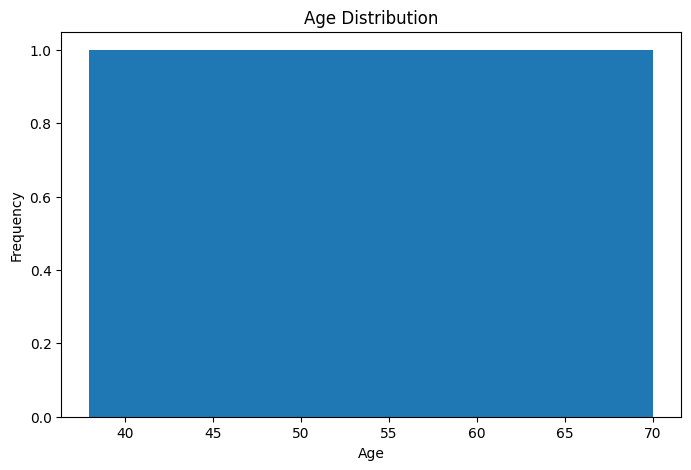

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_csv["Age"],
    bins=5
)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()

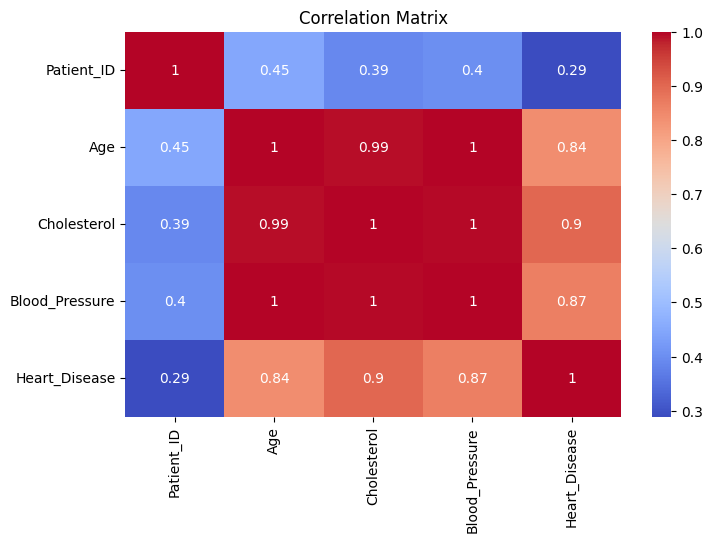

In [14]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df_csv.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

MEDICAL DATA — UCI CLEVELAND HEART DISEASE

In [15]:
url = "/content/heart_failure_clinical_records_dataset.csv"

heart_df = pd.read_csv(url)

display(heart_df.head())

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [16]:
print("Rows:", heart_df.shape[0])
print("Columns:", heart_df.shape[1])

print("\nColumns:")
print(heart_df.columns.tolist())

print("\nMissing values:")
print(heart_df.isnull().sum())

Rows: 299
Columns: 13

Columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [17]:
inspect_data(
    heart_df,
    "Heart Disease Medical Dataset"
)

DATASET: Heart Disease Medical Dataset

Data type:
<class 'pandas.core.frame.DataFrame'>

Shape:
(299, 13)

First 5 rows:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1



Data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Basic statistics:


,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [18]:
print(
    heart_df["DEATH_EVENT"].value_counts()
)

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


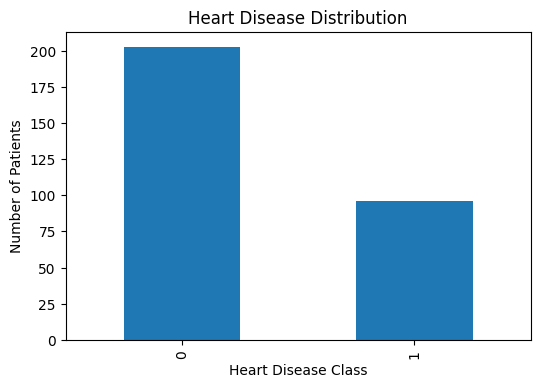

In [19]:
plt.figure(figsize=(6, 4))

heart_df["DEATH_EVENT"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Heart Disease Class")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Distribution")

plt.show()

medical preprocessing


In [21]:
X = heart_df.drop("DEATH_EVENT", axis=1)
y = heart_df["DEATH_EVENT"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
numeric_features = X.select_dtypes(
    include=np.number
).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        )
    ]
)

logistic regression

In [24]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [25]:
model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [26]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

model evaluation

In [27]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8166666666666667


In [28]:
auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", auc)

ROC-AUC: 0.858793324775353


In [29]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.93      0.87        41
           1       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60



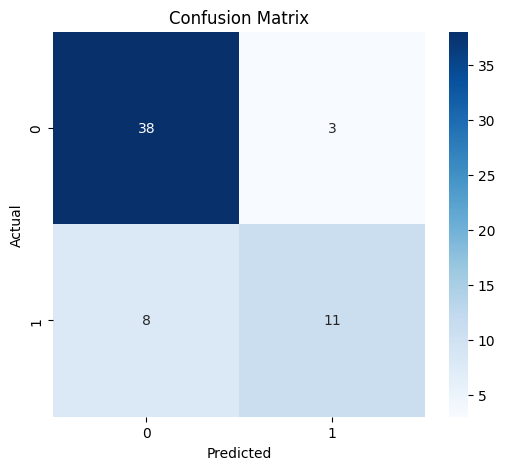

In [30]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

textual data

In [31]:
clinical_note = """
Patient is a 56-year-old male.
The patient reports chest pain during physical activity.
Blood pressure is elevated.
The patient also reports shortness of breath.
ECG examination is recommended.
"""

with open(
    "clinical_note.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(clinical_note)

read txt file

In [32]:
with open(
    "clinical_note.txt",
    "r",
    encoding="utf-8"
) as file:

    text = file.read()

print(text)


Patient is a 56-year-old male.
The patient reports chest pain during physical activity.
Blood pressure is elevated.
The patient also reports shortness of breath.
ECG examination is recommended.



best test cleaning

In [33]:
clean_text = text.lower()

clean_text = re.sub(
    r"[^a-z0-9\s]",
    "",
    clean_text
)

tokens = clean_text.split()

print(tokens)

['patient', 'is', 'a', '56yearold', 'male', 'the', 'patient', 'reports', 'chest', 'pain', 'during', 'physical', 'activity', 'blood', 'pressure', 'is', 'elevated', 'the', 'patient', 'also', 'reports', 'shortness', 'of', 'breath', 'ecg', 'examination', 'is', 'recommended']


word frequency

In [34]:
word_frequency = Counter(tokens)

print(
    word_frequency.most_common(10)
)

[('patient', 3), ('is', 3), ('the', 2), ('reports', 2), ('a', 1), ('56yearold', 1), ('male', 1), ('chest', 1), ('pain', 1), ('during', 1)]


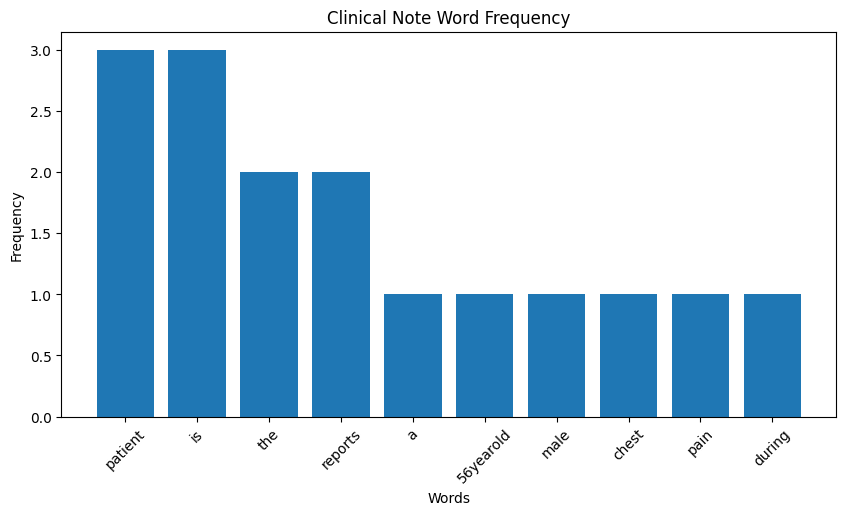

In [35]:
words = [
    item[0]
    for item in word_frequency.most_common(10)
]

counts = [
    item[1]
    for item in word_frequency.most_common(10)
]

plt.figure(figsize=(10, 5))

plt.bar(words, counts)

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Clinical Note Word Frequency")

plt.xticks(rotation=45)

plt.show()

stopword removal

In [36]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

filtered_tokens = [
    word
    for word in tokens
    if word not in stop_words
]

print(filtered_tokens)

['patient', '56yearold', 'male', 'patient', 'reports', 'chest', 'pain', 'physical', 'activity', 'blood', 'pressure', 'elevated', 'patient', 'also', 'reports', 'shortness', 'breath', 'ecg', 'examination', 'recommended']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


image dataset

In [37]:
image_array = np.random.randint(
    0,
    256,
    size=(256, 256),
    dtype=np.uint8
)

image = Image.fromarray(
    image_array
)

image.save(
    "sample_medical_image.png"
)


read image

In [38]:
img = Image.open(
    "sample_medical_image.png"
)

print("Image format:", img.format)
print("Image size:", img.size)
print("Image mode:", img.mode)

Image format: PNG
Image size: (256, 256)
Image mode: L


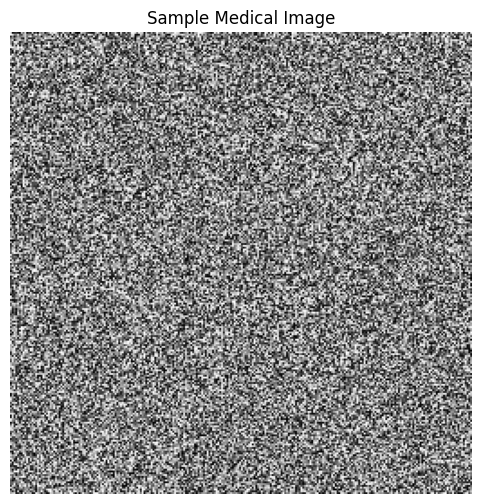

In [39]:
plt.figure(figsize=(6, 6))

plt.imshow(
    img,
    cmap="gray"
)

plt.axis("off")
plt.title("Sample Medical Image")

plt.show()

image preprocessing

In [40]:
resized_img = img.resize(
    (128, 128)
)

print(
    "Original size:",
    img.size
)

print(
    "New size:",
    resized_img.size
)

Original size: (256, 256)
New size: (128, 128)


In [41]:
img_array = np.array(
    resized_img
)

print("Shape:", img_array.shape)
print("Minimum:", img_array.min())
print("Maximum:", img_array.max())

Shape: (128, 128)
Minimum: 31
Maximum: 227


In [42]:
normalized_img = img_array / 255.0

print(
    "Normalized minimum:",
    normalized_img.min()
)

print(
    "Normalized maximum:",
    normalized_img.max()
)

Normalized minimum: 0.12156862745098039
Normalized maximum: 0.8901960784313725


image metadata

In [43]:
print(
    "Image information:"
)

print(img.info)

Image information:
{}


In [44]:
!pip install -q pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.3 MB/s eta 0:00:00


In [46]:
import pydicom



single data mit-bih-ecg

In [47]:
!pip install -q wfdb

In [48]:
import wfdb

In [49]:
record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

In [50]:
print("Signal shape:")
print(record.p_signal.shape)

print("\nSampling frequency:")
print(record.fs)

print("\nSignal names:")
print(record.sig_name)

Signal shape:
(650000, 2)

Sampling frequency:
360

Signal names:
['MLII', 'V5']


read ecg annotation

In [51]:
annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

In [52]:
print("Number of annotations:")
print(len(annotation.sample))

print("\nFirst 20 annotation samples:")
print(annotation.sample[:20])

print("\nFirst 20 symbols:")
print(annotation.symbol[:20])

Number of annotations:
2274

First 20 annotation samples:
[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]

First 20 symbols:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


plot ecg signal

In [53]:
fs = record.fs

seconds = 10

samples = int(
    seconds * fs
)

ecg = record.p_signal[
    :samples,
    0
]

time = np.arange(
    samples
) / fs

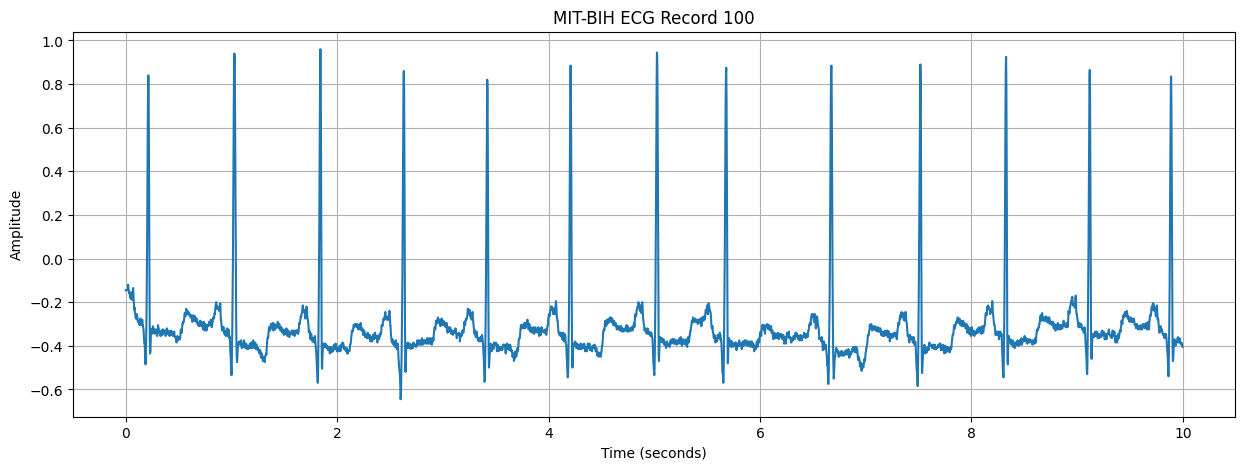

In [54]:
plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("MIT-BIH ECG Record 100")

plt.grid()

plt.show()

ecg heart rate calculation


In [58]:
beat_samples = annotation.sample[
    annotation.sample < len(record.p_signal)
]

beat_intervals = np.diff(
    beat_samples
) / record.fs

heart_rates = 60 / beat_intervals

In [59]:
valid_hr = heart_rates[
    (heart_rates > 30) &
    (heart_rates < 220)
]

print(
    "Average heart rate:",
    np.mean(valid_hr)
)

print(
    "Median heart rate:",
    np.median(valid_hr)
)

Average heart rate: 75.81687550869987
Median heart rate: 75.26132404181185


ecg beat interval statistics

In [60]:
print(
    "Number of detected intervals:",
    len(beat_intervals)
)

print(
    "Mean beat interval:",
    np.mean(beat_intervals),
    "seconds"
)

print(
    "Standard deviation:",
    np.std(beat_intervals),
    "seconds"
)

Number of detected intervals: 2273
Mean beat interval: 0.7943161265092633 seconds
Standard deviation: 0.05058434099145012 seconds


unified loader design

In [61]:
def load_data(file_path):

    extension = os.path.splitext(
        file_path
    )[1].lower()

    # Tabular
    if extension == ".csv":
        return pd.read_csv(file_path)

    elif extension in [".xls", ".xlsx"]:
        return pd.read_excel(file_path)

    elif extension == ".json":
        return pd.read_json(file_path)

    # Text
    elif extension == ".txt":
        with open(
            file_path,
            "r",
            encoding="utf-8"
        ) as file:
            return file.read()

    # Image
    elif extension in [
        ".png",
        ".jpg",
        ".jpeg",
        ".tif",
        ".tiff"
    ]:
        return Image.open(file_path)

    else:
        raise ValueError(
            f"Unsupported file format: {extension}"
        )

In [62]:
data = load_data(
    "patient_data.csv"
)

print(type(data))
display(data.head())

<class 'pandas.core.frame.DataFrame'>


,Patient_ID,Age,Gender,Cholesterol,Blood_Pressure,Heart_Disease
0,101,45,M,210,130,0
1,102,52,F,240,140,1
2,103,61,M,260,150,1
3,104,38,F,190,120,0
4,105,70,M,280,160,1


In [63]:
text_data = load_data(
    "clinical_note.txt"
)

print(type(text_data))
print(text_data)

<class 'str'>

Patient is a 56-year-old male.
The patient reports chest pain during physical activity.
Blood pressure is elevated.
The patient also reports shortness of breath.
ECG examination is recommended.



In [64]:
image_data = load_data(
    "sample_medical_image.png"
)

print(type(image_data))
print(image_data.size)

<class 'PIL.PngImagePlugin.PngImageFile'>
(256, 256)


In [65]:
multimodal_dataset = {
    "patient_id": "P001",

    "tabular": {
        "age": 56,
        "sex": "M",
        "blood_pressure": 145,
        "cholesterol": 240
    },

    "text": {
        "clinical_note": clinical_note
    },

    "image": {
        "path": "sample_medical_image.png"
    },

    "signal": {
        "record": "100",
        "sampling_frequency": record.fs
    }
}

In [66]:
print(
    multimodal_dataset
)

{'patient_id': 'P001', 'tabular': {'age': 56, 'sex': 'M', 'blood_pressure': 145, 'cholesterol': 240}, 'text': {'clinical_note': '\nPatient is a 56-year-old male.\nThe patient reports chest pain during physical activity.\nBlood pressure is elevated.\nThe patient also reports shortness of breath.\nECG examination is recommended.\n'}, 'image': {'path': 'sample_medical_image.png'}, 'signal': {'record': '100', 'sampling_frequency': 360}}
